#  Personal Finance Dashboard
### 12 months of income, expenses and savings
Tools:Pandas | Matplotlib | NumPy


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


In [3]:

# 1. SAMPLE DATA (12 months)

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

income = [2500, 2500, 2700, 2500, 2600, 2800,
          2500, 2500, 2700, 2600, 2800, 3000]

expenses = {
    "Rent":        [800]*12,
    "Food":        [300, 320, 280, 310, 290, 350, 300, 280, 310, 320, 330, 400],
    "Transport":   [100, 90,  110, 100, 95,  120, 100, 100, 110, 105, 100, 120],
    "Utilities":   [80,  85,  75,  80,  70,  90,  85,  80,  75,  80,  85,  90],
    "Entertainment":[60, 80,  70,  90,  100, 120, 80,  60,  90,  100, 150, 200],
    "Healthcare":  [0,   50,  0,   0,   30,  0,   0,   50,  0,   0,   0,   0],
    "Savings":     [200, 200, 250, 200, 200, 250, 200, 200, 250, 200, 250, 300],
    "Other":       [50,  60,  70,  50,  55,  60,  50,  55,  60,  55,  60,  80],
}



In [5]:
# 2. BUILD DATAFRAME

df = pd.DataFrame(expenses, index=months)
df["Total Expenses"] = df.sum(axis=1)
df["Income"]         = income
df["Net Savings"]    = df["Income"] - df["Total Expenses"]
df["Savings Rate %"] = (df["Net Savings"] / df["Income"] * 100).round(1)

print("=" * 55)
print("       PERSONAL FINANCE SUMMARY (Annual)")
print("=" * 55)
print(f"  Total Annual Income:    £{df['Income'].sum():,.0f}")
print(f"  Total Annual Expenses:  £{df['Total Expenses'].sum():,.0f}")
print(f"  Total Net Savings:      £{df['Net Savings'].sum():,.0f}")
print(f"  Avg Savings Rate:       {df['Savings Rate %'].mean():.1f}%")
print("=" * 55)
print()
print(df[["Income", "Total Expenses", "Net Savings", "Savings Rate %"]].to_string())



       PERSONAL FINANCE SUMMARY (Annual)
  Total Annual Income:    £31,700
  Total Annual Expenses:  £20,350
  Total Net Savings:      £11,350
  Avg Savings Rate:       35.8%

     Income  Total Expenses  Net Savings  Savings Rate %
Jan    2500            1590          910            36.4
Feb    2500            1685          815            32.6
Mar    2700            1655         1045            38.7
Apr    2500            1630          870            34.8
May    2600            1640          960            36.9
Jun    2800            1790         1010            36.1
Jul    2500            1615          885            35.4
Aug    2500            1625          875            35.0
Sep    2700            1695         1005            37.2
Oct    2600            1660          940            36.2
Nov    2800            1775         1025            36.6
Dec    3000            1990         1010            33.7


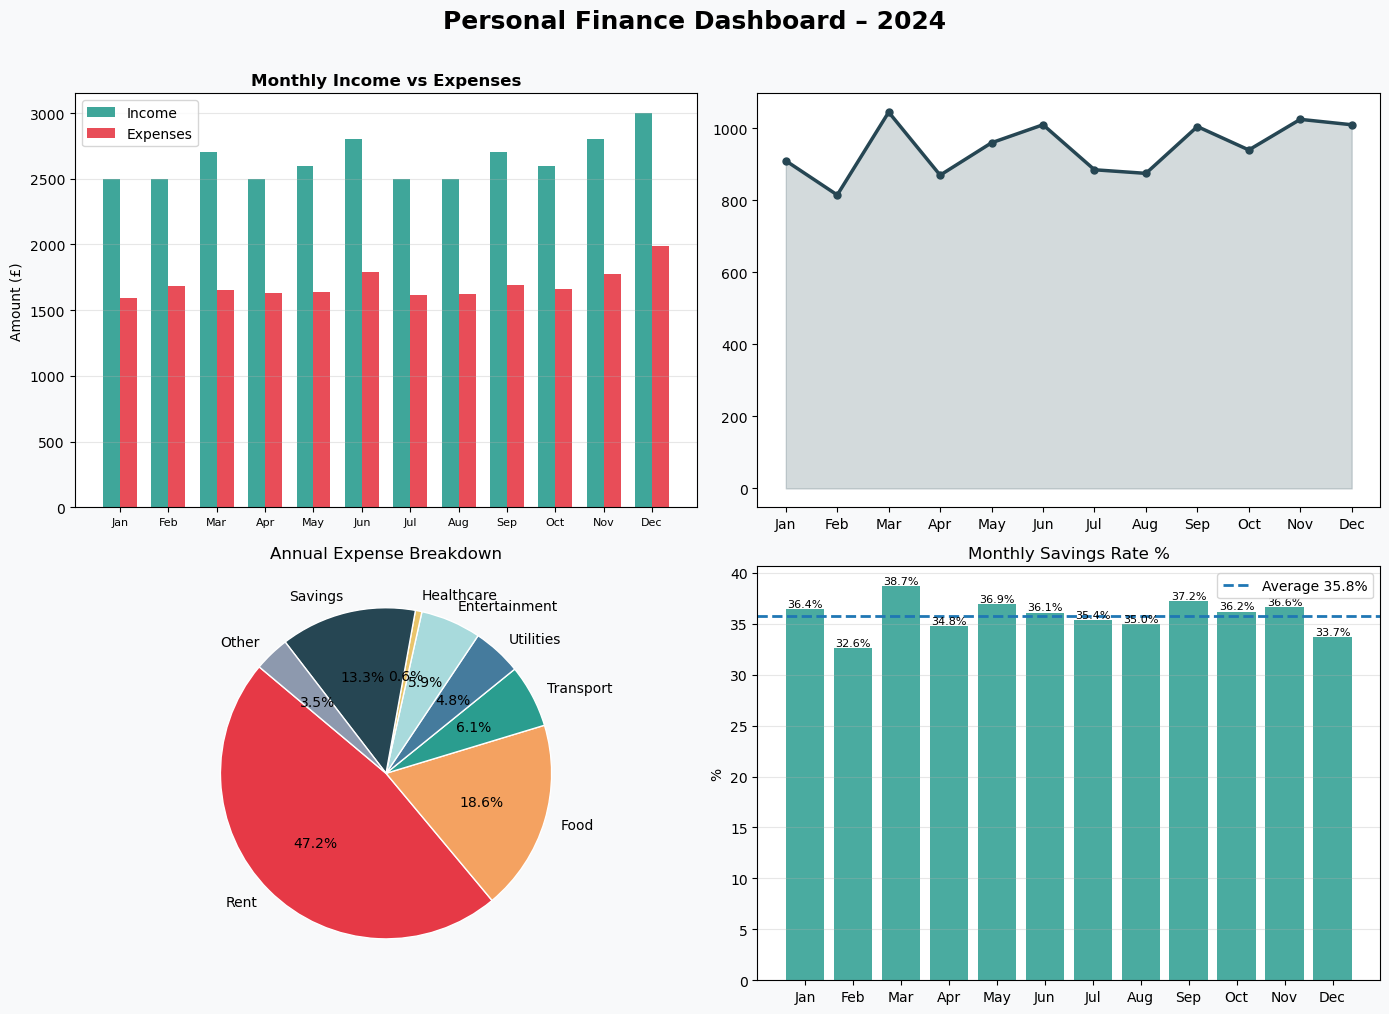

In [15]:
# 3. VISUALISATIONS
colors = {
    "Rent": "#E63946",
    "Food": "#F4A261",
    "Transport": "#2A9D8F",
    "Utilities": "#457B9D",
    "Entertainment": "#A8DADC",
    "Healthcare": "#E9C46A",
    "Savings": "#264653",
    "Other": "#8D99AE",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Personal Finance Dashboard – 2024", fontsize=18, fontweight="bold", y=1.01)
fig.patch.set_facecolor("#F8F9FA")

# Chart 1: Income vs Expenses (bar chart)
ax1 = axes[0, 0]
x = np.arange(len(months))
w = 0.35
ax1.bar(x - w/2, df["Income"], width=w, label="Income", color="#2A9D8F", alpha=0.9)
ax1.bar(x + w/2, df["Total Expenses"], width=w, label="Expenses", color="#E63946", alpha=0.9)
ax1.set_title("Monthly Income vs Expenses", fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(months, fontsize=8)
ax1.set_ylabel("Amount (£)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)
ax1.set_facecolor("#FFFFFF")

# Chart 2: Net Savings trend (line chart)
ax2 = axes[0, 1]
ax2.fill_between(months, df["Net Savings"], color="#264653", alpha=0.2)
ax2.plot(months, df["Net Savings"], color="#264653", linewidth=2.5, marker="o", markersize=5)
# chart 3
ax3 = axes[1, 0]

annual = {cat: df[cat].sum() for cat in expenses}

pie_colors = [colors[c] for c in annual.keys()]

ax3.pie(
    annual.values(),
    labels=annual.keys(),
    autopct="%1.1f%%",
    startangle=140,
    colors=pie_colors,
    wedgeprops=dict(edgecolor="white", linewidth=1)
)

ax3.set_title("Annual Expense Breakdown")
# chart 4
ax4 = axes[1, 1]

bars = ax4.bar(
    months,
    df["Savings Rate %"],
    color="#2A9D8F",
    alpha=0.85
)

avg = df["Savings Rate %"].mean()

ax4.axhline(
    avg,
    linestyle="--",
    linewidth=2,
    label=f"Average {avg:.1f}%"
)

ax4.set_title("Monthly Savings Rate %")
ax4.set_ylabel("%")
ax4.legend()
ax4.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, df["Savings Rate %"]):
    ax4.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{val:.1f}%",
        ha="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()
